In [1]:
# ======================================================================
# Importação das Bibliotecas Necessárias
# ======================================================================
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# ======================================================================
# Definição das Sementes
# ======================================================================
SEMENTE = 1965
random.seed(SEMENTE)
np.random.seed(SEMENTE)


In [3]:
# ======================================================================
# Definição das Categorias
# ======================================================================
categories = ['world','sports','tech','finance','entertainment']


In [4]:
# ======================================================================
# Definição da Relação de Cliques
# ======================================================================
P_click = [
    # world  sports  tech   finance  entertainment
    [0.25,  0.10,   0.15,  0.20,    0.18],   # seg 0 (world/finance)
    [0.08,  0.35,   0.10,  0.12,    0.16],   # seg 1 (sports)
    [0.10,  0.12,   0.40,  0.16,    0.20],   # seg 2 (tech)
    [0.12,  0.15,   0.18,  0.38,    0.22],   # seg 3 (finance)
]


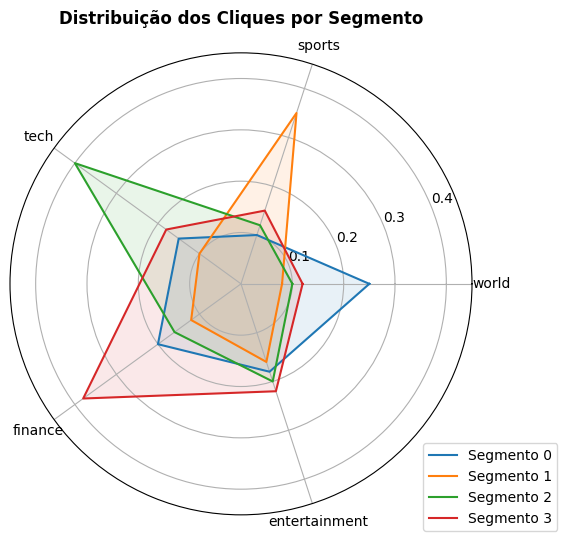

In [14]:

# Ajuste para radar chart
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fechar o gráfico

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Plotar cada segmento
labels = ["Segmento 0", "Segmento 1", "Segmento 2", "Segmento 3"]
for idx, row in enumerate(P_click):
    values = row + row[:1]  # fechar o gráfico
    ax.plot(angles, values, label=labels[idx])
    ax.fill(angles, values, alpha=0.1)

# Ajustes do gráfico
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticks([0.1, 0.2, 0.3, 0.4])
ax.set_yticklabels(["0.1", "0.2", "0.3", "0.4"])
ax.set_ylim(0, 0.45)
ax.set_title("Distribuição dos Cliques por Segmento\n", size=12, weight="bold")
ax.legend(
    loc='lower right',           # canto inferior direito
    bbox_to_anchor=(1.2, -0.05) # ajusta a posição horizontal e vertical
)

plt.show()


In [188]:
# ======================================================================
# Simulação de usuários
# ======================================================================
usuarios = [
    # (nome, tipo, payload)
    ("Ana",     "segment", {"segment_id": 2}),                  # tech
    ("Bruno",   "segment", {"segment_id": 1}),                  # sports
    ("Carla",   "mixture", {"weights": [0.3, 0.1, 0.2, 0.4]}),  # 40% finance, 30% world...
    ("Diego",   "segment", {"segment_id": 3}),                  # finance
    ("Eva",     "mixture", {"weights": [0.5, 0.1, 0.3, 0.1]}),  # world/tech
]

In [189]:
def make_transition_matrix(p_switch: float, S: int) -> np.ndarray:
    if S < 2:
        return np.array([[1.0]], dtype=np.float32)
    P = np.full((S, S), p_switch/(S-1), dtype=np.float32)
    for s in range(S):
        P[s, s] = 1.0 - p_switch
    return P


In [190]:
def make_env(P_click, p_switch=0.08, episode_len=50, seed=123):
    P_click = np.array(P_click, dtype=np.float32)  # [S, A]
    S, A = P_click.shape
    P_trans = make_transition_matrix(p_switch, S)
    rng = np.random.default_rng(seed)
    return {
        "P_click": P_click,     # [S, A]
        "P_trans": P_trans,     # [S, S]
        "S": S,
        "A": A,
        "episode_len": int(episode_len),
        "seed": seed,
        "rng": rng,
    }


In [191]:
def reset_env(env, state=None):
    rng = env["rng"]
    S = env["S"]
    s0 = int(rng.integers(0, S)) if state is None else int(state)
    return s0, 0


In [192]:
def step_env(env, state, action, t):
    P_click = env["P_click"]
    P_trans = env["P_trans"]
    episode_len = env["episode_len"]
    rng = env["rng"]

    p = float(P_click[state, action])
    reward = 1 if rng.random() < p else 0

    next_state = int(rng.choice(env["S"], p=P_trans[state]))
    t_next = t + 1
    done = t_next >= episode_len
    return next_state, reward, done, t_next


In [193]:
def epsilon_greedy(Q, state, epsilon, rng, A):
    if rng.random() < epsilon:
        return int(rng.integers(0, A))
    noise = rng.random(A) / 1000.0
    return int(np.argmax(Q[state] + noise))


In [194]:
def q_update(Q, state, action, reward, next_state, alpha, gamma):
    best_next = np.max(Q[next_state])
    Q[state, action] = (1 - alpha) * Q[state, action] + alpha * (reward + gamma * best_next)
    return Q



In [195]:
def train(env,
          episodes=1500,
          alpha=0.20,
          gamma=0.90,
          epsilon=1.00,
          epsilon_final=0.05,
          epsilon_decay=0.995,
          decay_per_step=True, debug=False):
    S, A, rng = env["S"], env["A"], env["rng"]
    Q = np.zeros((S, A), dtype=np.float32)

    ctr_hist = []     # CTR por episódio (cliques/steps)
    eps_hist = []     # epsilon ao fim de cada episódio

    for ep in range(episodes):
        state, t = reset_env(env)
        clicks = 0
        steps  = 0
        done = False

        while not done:
            action = epsilon_greedy(Q, state, epsilon, rng, A)
            next_state, reward, done, t = step_env(env, state, action, t)
            Q = q_update(Q, state, action, reward, next_state, alpha, gamma)
            state = next_state
            clicks += reward
            steps  += 1

            # decaimento por passo
            if decay_per_step and epsilon > epsilon_final:
                epsilon *= epsilon_decay

        # decaimento por episódio (se preferir)
        if (not decay_per_step) and epsilon > epsilon_final:
            epsilon *= epsilon_decay

        ctr_hist.append(clicks / max(1, steps))
        eps_hist.append(epsilon)

        if debug:
            if (ep + 1) % 100 == 0:
                print(f"Ep {ep+1:4d} | CTR: {ctr_hist[-1]:.3f} | ε: {epsilon:.3f}")

    logs = {"ctr_hist": ctr_hist, "eps_hist": eps_hist}
    return Q, logs


In [196]:
def evaluate(env, Q, episodes=300):
    total_clicks, total_steps = 0, 0
    for _ in range(episodes):
        state, t = reset_env(env)
        done = False
        while not done:
            action = int(np.argmax(Q[state]))
            state, reward, done, t = step_env(env, state, action, t)
            total_clicks += reward
            total_steps  += 1
    return total_clicks / max(1, total_steps)


In [197]:
def top_n_actions_for_state(Q, state, categories, topn=3):
    scores = Q[state].copy()
    order = np.argsort(scores)[::-1]
    recs = [(categories[a], float(scores[a])) for a in order[:topn]]
    return recs


In [198]:
def recommend_for_segment(Q, segment_id, categories, topn=3):
    recs = top_n_actions_for_state(Q, segment_id, categories, topn=topn)
    return recs



In [199]:
def recommend_for_mixture(Q, segment_weights, categories, topn=3):
    w = np.array(segment_weights, dtype=np.float32)
    w = w / max(1e-8, w.sum())
    expected_Q = w @ Q  # [A]
    order = np.argsort(expected_Q)[::-1]
    recs = [(categories[a], float(expected_Q[a])) for a in order[:topn]]
    return recs

In [200]:
def Mostra_CTR_Episodio (logs) -> None:
    plt.figure(figsize=(10,5))
    plt.plot(logs["ctr_hist"], lw=2)
    plt.xlabel("Episódio"); plt.ylabel("CTR")
    plt.title("CTR por episódio (treino)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [201]:
def Mostra_Decaimento_Epsilon (logs) -> None:
    plt.figure(figsize=(10,5))
    plt.plot(logs["eps_hist"], lw=2)
    plt.xlabel("Episódio"); plt.ylabel("ε")
    plt.title("Decaimento de ε")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [202]:
def Mostra_Heatmap (Q):
    plt.figure(figsize=(8, 6))
    sns.heatmap(Q, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True)

    # Títulos e rótulos
    plt.title("Heatmap da Tabela Q Aprendida", fontsize=14)
    plt.xlabel("Ações", fontsize=12)
    plt.ylabel("Estados", fontsize=12)

    plt.show()

In [203]:
# ======================================================================
# Criação do Ambiente e Treinamento
# ======================================================================
env = make_env(P_click=P_click, p_switch=0.08, episode_len=50, seed=123)
Q, logs = train(
                env,
                episodes=2000,
                alpha=0.2,
                gamma=0.9,
                epsilon=1.0,
                epsilon_final=0.05,
                epsilon_decay=0.997,
                decay_per_step=True,
                debug=False
           )



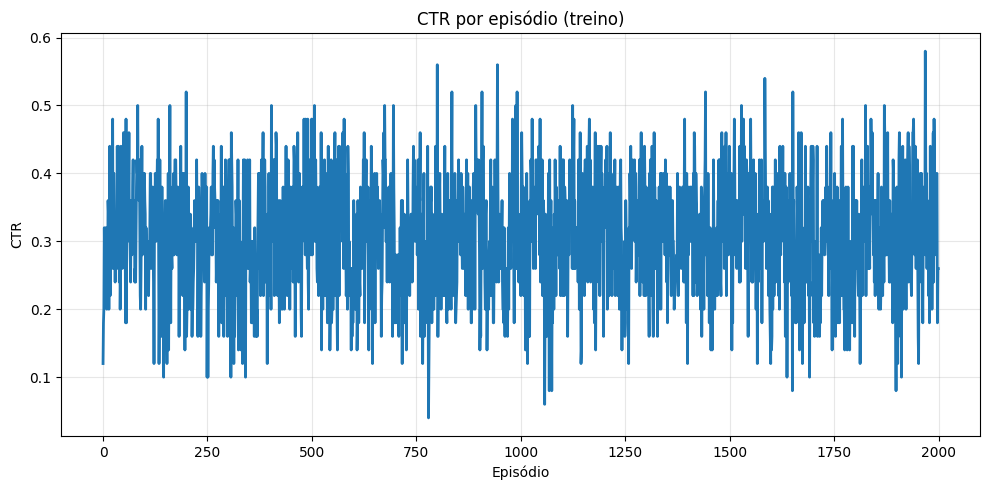

In [204]:
# ======================================================================
# Mostra o CTR por Episódio
# ======================================================================
Mostra_CTR_Episodio (logs)


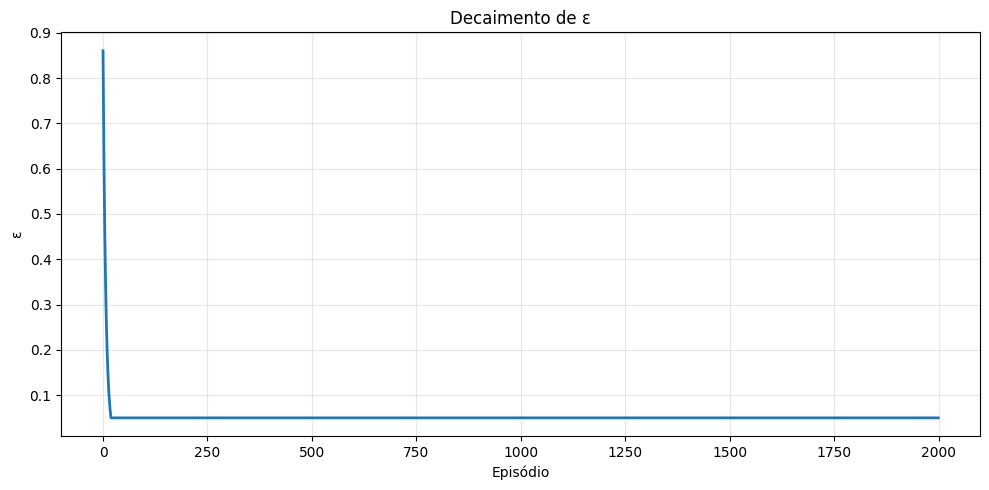

In [205]:
# ======================================================================
# Mostra o Decaímento Epsilon
# ======================================================================
Mostra_Decaimento_Epsilon (logs)


In [159]:
# ======================================================================
# Cálculo do CTR (click-through rate)
# ======================================================================
ctr = evaluate(env, Q, episodes=500)
print ("# ======================================================================")
print ("# CTR Médio")
print ("# ======================================================================")
print (f"# CTR médio (política greedy) após treino: {ctr:.3f}")
print ("# ======================================================================")


# ======================================================================
# CTR Médio
# ======================================================================
# CTR médio (política greedy) após treino: 0.322
# ======================================================================


In [160]:
# ======================================================================
# Tabela Q Aprendida
# ======================================================================
print ("# ======================================================================")
print ("# Tabela Q Aprendida")
print ("# ======================================================================")
print (Q)
print ("# ======================================================================")

# ======================================================================
# Tabela Q Aprendida
# ======================================================================
[[2.2790802 2.281429  2.8625236 2.209454  2.2574415]
 [2.8815181 3.3181725 2.9647338 2.65851   2.8513017]
 [3.044528  3.0131373 3.582347  3.0219193 3.0493743]
 [2.8873184 2.9205072 3.3180299 3.510298  3.2854362]]
# ======================================================================


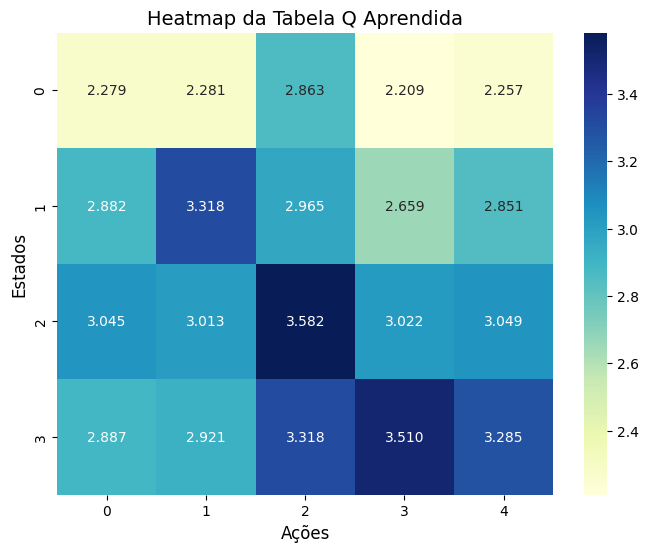

In [161]:
# ======================================================================
# Mostra Heatmap da Tabela Q
# ======================================================================
Mostra_Heatmap (Q)


In [162]:
# ======================================================================
# Recomendações por usuário (usando Q aprendido)
# ======================================================================
TOPN = 3
print ("# ======================================================================")
print ("# Recomendações por usuário (usando Q aprendido)")
print ("# ======================================================================")
for nome, tipo, payload in usuarios:
    if tipo == "segment":
        seg = payload["segment_id"]
        recs = recommend_for_segment(Q, seg, categories, topn=TOPN)
        print(f"# {nome} (segmento {seg}): {recs}")
    elif tipo == "mixture":
        w = payload["weights"]
        recs = recommend_for_mixture(Q, w, categories, topn=TOPN)
        print(f"# {nome} (mistura {w}): {recs}")
print ("# ======================================================================")


# ======================================================================
# Recomendações por usuário (usando Q aprendido)
# ======================================================================
# Ana (segmento 2): [('tech', 3.5823469161987305), ('entertainment', 3.0493743419647217), ('world', 3.044528007507324)]
# Bruno (segmento 1): [('sports', 3.3181724548339844), ('tech', 2.964733839035034), ('world', 2.8815181255340576)]
# Carla (mistura [0.3, 0.1, 0.2, 0.4]): [('tech', 3.198911666870117), ('finance', 2.937190532684326), ('entertainment', 2.8864121437072754)]
# Diego (segmento 3): [('finance', 3.510298013687134), ('tech', 3.3180298805236816), ('entertainment', 3.2854361534118652)]
# Eva (mistura [0.5, 0.1, 0.3, 0.1]): [('tech', 3.134242296218872), ('sports', 2.6685237884521484), ('entertainment', 2.6572070121765137)]
# ======================================================================


In [ ]:
# ======================================================================
# FIM DO PROGRAMA
# ======================================================================